In [1]:
# !pip install tensorflow scikit-learn matplotlib seaborn pandas numpy tqdm

In [2]:
# ── RESET WORKSPACE (Run ONCE before fresh start) ─────────────────────────────
import shutil, os
WORK_DIR_RESET = './efficientnetv2s_workspace'
if os.path.exists(WORK_DIR_RESET):
    shutil.rmtree(WORK_DIR_RESET)
    print(f'✅ Old workspace deleted: {WORK_DIR_RESET}')
else:
    print('ℹ️ No old workspace found — clean start')

✅ Old workspace deleted: ./efficientnetv2s_workspace


In [3]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import os, json, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(f'TensorFlow: {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

# EfficientNetV2S requires TensorFlow >= 2.8
tf_ver = tuple(int(x) for x in tf.__version__.split('.')[:2])
assert tf_ver >= (2, 8), f'TF >= 2.8 required for EfficientNetV2S, got {tf.__version__}'
print('✅ TensorFlow version OK')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow: 2.21.0
GPUs: []
✅ TensorFlow version OK


In [4]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
# ⚠️  EfficientNetV2S recommended input: 384x384 (ImageNet21k-ft1k weights).
#     Using 300x300 here as a practical compromise — lower VRAM, faster training.
#     Change to (384, 384) for maximum accuracy if VRAM allows.
DATASET_ROOT  = r'C:\Users\Admin\Desktop\dataset train\Dataset'
WORK_DIR      = './efficientnetv2s_workspace'

IMG_SIZE      = (300, 300)   # 300x300 practical; change to (384,384) for full accuracy
BATCH_SIZE    = 16           # Reduced vs DenseNet — EfficientNetV2S is larger
EPOCHS_FROZEN = 10
EPOCHS_FINE   = 30
LEARNING_RATE = 1e-4
FINE_LR       = 1e-5

TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
TEST_RATIO    = 0.15
MODEL_NAME    = 'EfficientNetV2S'

os.makedirs(WORK_DIR, exist_ok=True)
print('Config ready ✅')

Config ready ✅


In [5]:
# ── DATA SPLIT (resume-safe) ──────────────────────────────────────────────────
SPLIT_CSV = os.path.join(WORK_DIR, 'data_split.csv')

def build_split(dataset_root, train_r, val_r, test_r, seed):
    records = []
    dataset_root = Path(dataset_root)
    for cls_dir in sorted(dataset_root.iterdir()):
        if not cls_dir.is_dir(): continue
        label = cls_dir.name
        files = [str(p) for p in cls_dir.glob('**/*') if p.suffix.lower() in ('.jpg','.jpeg','.png')]
        for f in files:
            records.append({'filepath': f, 'label': label})
    df = pd.DataFrame(records)
    print(f'Total images: {len(df)}')
    print(df['label'].value_counts())
    train_df, tmp = train_test_split(df, test_size=(1-train_r), stratify=df['label'], random_state=seed)
    rel_val = val_r / (val_r + test_r)
    val_df, test_df = train_test_split(tmp, test_size=(1-rel_val), stratify=tmp['label'], random_state=seed)
    train_df = train_df.copy(); train_df['split'] = 'train'
    val_df   = val_df.copy();   val_df['split']   = 'val'
    test_df  = test_df.copy();  test_df['split']  = 'test'
    return pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

if os.path.exists(SPLIT_CSV):
    print('⚡ Loading saved split ...')
    df_split = pd.read_csv(SPLIT_CSV)
else:
    print('🔨 Building new split ...')
    df_split = build_split(DATASET_ROOT, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, SEED)
    df_split.to_csv(SPLIT_CSV, index=False)
    print(f'Saved → {SPLIT_CSV}')

train_df = df_split[df_split['split']=='train'].reset_index(drop=True)
val_df   = df_split[df_split['split']=='val'].reset_index(drop=True)
test_df  = df_split[df_split['split']=='test'].reset_index(drop=True)

CLASS_NAMES = sorted(df_split['label'].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)
label2idx   = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
assert NUM_CLASSES == 4, f'Expected 4 classes, got {NUM_CLASSES}! Check DATASET_ROOT path.'
print('✅ Classes verified: 4 classes found')

🔨 Building new split ...
Total images: 9209
label
Normal                 3271
Pneumonia-Bacterial    3001
Pneumonia-Viral        1656
COVID                  1281
Name: count, dtype: int64
Saved → ./efficientnetv2s_workspace\data_split.csv
Train: 6446 | Val: 1381 | Test: 1382
Classes (4): ['COVID', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']
✅ Classes verified: 4 classes found


In [6]:
# ── DATA GENERATORS ───────────────────────────────────────────────────────────
# EfficientNetV2S note:
#   The model is loaded with include_preprocessing=False (Keras default when
#   include_top=False), so standard rescale=1./255 normalization is applied here.
#   This is consistent with the DenseNet121 notebook approach.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

def make_gen(datagen, df, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe=df, x_col='filepath', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASS_NAMES,   # ← explicit class order
        shuffle=shuffle, seed=SEED
    )

train_gen = make_gen(train_datagen, train_df, shuffle=True)
val_gen   = make_gen(val_test_datagen, val_df, shuffle=False)
test_gen  = make_gen(val_test_datagen, test_df, shuffle=False)

print(f'Train batches: {len(train_gen)} | Val: {len(val_gen)} | Test: {len(test_gen)}')
print(f'Class indices: {train_gen.class_indices}')
assert len(train_gen.class_indices) == 4, 'Generator sees wrong number of classes!'
print('✅ Generator verified: 4 classes')

Found 6446 validated image filenames belonging to 4 classes.
Found 1381 validated image filenames belonging to 4 classes.
Found 1382 validated image filenames belonging to 4 classes.
Train batches: 403 | Val: 87 | Test: 87
Class indices: {'COVID': 0, 'Normal': 1, 'Pneumonia-Bacterial': 2, 'Pneumonia-Viral': 3}
✅ Generator verified: 4 classes


In [7]:
# ── CLASS WEIGHTS ─────────────────────────────────────────────────────────────
y_train = train_df['label'].map(label2idx).values
cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weights = {i: w for i, w in enumerate(cw)}
print('Class weights:', class_weights)

Class weights: {0: 1.7965440356744704, 1: 0.7040192223678462, 2: 0.7670157068062827, 3: 1.3904227782571181}


In [8]:
# ── BUILD MODEL ───────────────────────────────────────────────────────────────
def build_efficientnetv2s(num_classes, img_size):
    base = EfficientNetV2S(
        include_top=False,
        weights='imagenet',
        input_shape=(*img_size, 3),
        # include_preprocessing=False so our 1./255 rescale is applied correctly
    )
    base.trainable = False  # Freeze all backbone layers (Phase 1)

    inputs = keras.Input(shape=(*img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model, base

model, base_model = build_efficientnetv2s(NUM_CLASSES, IMG_SIZE)

print(f'Model output shape: {model.output_shape}')  # Should be (None, 4)
assert model.output_shape[-1] == 4, f'Output neurons should be 4, got {model.output_shape[-1]}'
print('✅ Model output verified: 4 neurons')
print(f'Total layers in EfficientNetV2S backbone: {len(base_model.layers)}')
model.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 93s 1us/step
Model output shape: (None, 4)
✅ Model output verified: 4 neurons
Total layers in EfficientNetV2S backbone: 513


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 10, 10, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,708 (80.58 MB)

 Trainable params: 790,788 (3.02 MB)

 Non-trainable params: 20,333,920 (77.57 MB)

In [9]:
# ── CALLBACKS & STATE ─────────────────────────────────────────────────────────
CKPT_FROZEN = os.path.join(WORK_DIR, 'ckpt_phase1_frozen.keras')
CKPT_FINE   = os.path.join(WORK_DIR, 'ckpt_phase2_finetune.keras')
BEST_MODEL  = os.path.join(WORK_DIR, 'best_model.keras')
LOG_FROZEN  = os.path.join(WORK_DIR, 'log_phase1.csv')
LOG_FINE    = os.path.join(WORK_DIR, 'log_phase2.csv')
STATE_FILE  = os.path.join(WORK_DIR, 'train_state.json')

def get_callbacks(ckpt_path, log_path):
    return [
        ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1),
        CSVLogger(log_path, append=True)
    ]

def save_state(phase):
    with open(STATE_FILE, 'w') as f:
        json.dump({'completed_phase': phase}, f)

def load_state():
    if os.path.exists(STATE_FILE):
        with open(STATE_FILE) as f:
            return json.load(f).get('completed_phase', 0)
    return 0

def get_metrics():
    return [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]

completed_phase = load_state()
print(f'Resuming from completed phase: {completed_phase}')

Resuming from completed phase: 0


In [10]:
# ── PHASE 1: FROZEN BACKBONE ──────────────────────────────────────────────────
if completed_phase < 1:
    print('\n🚀 Phase 1: Training head (backbone frozen) ...')

    if os.path.exists(CKPT_FROZEN):
        print('  ↩️  Resuming from Phase-1 checkpoint ...')
        model = keras.models.load_model(CKPT_FROZEN)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=get_metrics()
    )

    model.fit(
        train_gen,
        epochs=EPOCHS_FROZEN,
        validation_data=val_gen,
        class_weight=class_weights,
        callbacks=get_callbacks(CKPT_FROZEN, LOG_FROZEN),
        verbose=1
    )

    save_state(1)
    print('✅ Phase 1 complete!')
else:
    print('⚡ Phase 1 already done — loading checkpoint ...')
    model = keras.models.load_model(CKPT_FROZEN)


🚀 Phase 1: Training head (backbone frozen) ...
Epoch 1/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4396 - auc: 0.6976 - loss: 1.4375 - precision: 0.5061 - recall: 0.2947
Epoch 1: val_accuracy improved from None to 0.59377, saving model to ./efficientnetv2s_workspace\ckpt_phase1_frozen.keras

Epoch 1: finished saving model to ./efficientnetv2s_workspace\ckpt_phase1_frozen.keras
403/403 ━━━━━━━━━━━━━━━━━━━━ 943s 2s/step - accuracy: 0.4895 - auc: 0.7445 - loss: 1.3374 - precision: 0.5512 - recall: 0.3473 - val_accuracy: 0.5938 - val_auc: 0.8471 - val_loss: 1.1623 - val_precision: 0.8532 - val_recall: 0.2440 - learning_rate: 1.0000e-04
Epoch 2/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5475 - auc: 0.7965 - loss: 1.1906 - precision: 0.6053 - recall: 0.4161
Epoch 2: val_accuracy improved from 0.59377 to 0.62129, saving model to ./efficientnetv2s_workspace\ckpt_phase1_frozen.keras

Epoch 2: finished saving model to ./efficientnetv2s_workspace\ckpt_phase1_frozen.ker

In [11]:
# ── PHASE 2: FINE-TUNING ──────────────────────────────────────────────────────
# EfficientNetV2S fine-tuning strategy:
#   Architecture blocks: stem → block1 (FusedMBConv) → ... → block6 (MBConv) → top
#   We unfreeze block5 + block6 + top layers (last ~40% of backbone).
#   Blocks 1-4 remain frozen to preserve learned low-level features.
if completed_phase < 2:
    print('\n🔓 Phase 2: Fine-tuning top blocks of EfficientNetV2S (block5, block6, top) ...')

    if os.path.exists(CKPT_FINE):
        print('  ↩️  Resuming from Phase-2 checkpoint ...')
        model = keras.models.load_model(CKPT_FINE)
    else:
        # Identify the EfficientNetV2S base inside the functional model
        effnet_base = None
        for layer in model.layers:
            if isinstance(layer, tf.keras.Model) and 'efficientnet' in layer.name.lower():
                effnet_base = layer
                break

        if effnet_base is not None:
            # Freeze all layers first, then selectively unfreeze top blocks
            for layer in effnet_base.layers:
                layer.trainable = False

            # Unfreeze block5, block6, and top conv layers
            UNFREEZE_PREFIXES = ('block5', 'block6', 'top_')
            for layer in effnet_base.layers:
                if any(layer.name.startswith(p) for p in UNFREEZE_PREFIXES):
                    layer.trainable = True

            unfrozen = sum(1 for l in effnet_base.layers if l.trainable)
            total    = len(effnet_base.layers)
            print(f'  ✅ Unfrozen {unfrozen}/{total} layers in EfficientNetV2S backbone')
            print(f'     Unfrozen layers (first 15): '
                  f'{[l.name for l in effnet_base.layers if l.trainable][:15]}')
        else:
            print('  ⚠️ Could not find EfficientNetV2S base — unfreezing all')
            for layer in model.layers:
                layer.trainable = True

    # Lower LR for fine-tuning to avoid destroying pretrained weights
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=FINE_LR),
        loss='categorical_crossentropy',
        metrics=get_metrics()
    )

    model.fit(
        train_gen,
        epochs=EPOCHS_FINE,
        validation_data=val_gen,
        class_weight=class_weights,
        callbacks=get_callbacks(CKPT_FINE, LOG_FINE),
        verbose=1
    )

    save_state(2)
    shutil.copy(CKPT_FINE, BEST_MODEL)
    print('✅ Phase 2 complete!')
else:
    print('⚡ Phase 2 already done — loading best model ...')
    model = keras.models.load_model(BEST_MODEL)


🔓 Phase 2: Fine-tuning top blocks of EfficientNetV2S (block5, block6, top) ...
  ✅ Unfrozen 359/513 layers in EfficientNetV2S backbone
     Unfrozen layers (first 15): ['block5a_expand_conv', 'block5a_expand_bn', 'block5a_expand_activation', 'block5a_dwconv2', 'block5a_bn', 'block5a_activation', 'block5a_se_squeeze', 'block5a_se_reshape', 'block5a_se_reduce', 'block5a_se_expand', 'block5a_se_excite', 'block5a_project_conv', 'block5a_project_bn', 'block5b_expand_conv', 'block5b_expand_bn']
Epoch 1/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.4466 - auc: 0.7250 - loss: 1.3882 - precision: 0.5154 - recall: 0.3303
Epoch 1: val_accuracy improved from None to 0.59377, saving model to ./efficientnetv2s_workspace\ckpt_phase2_finetune.keras

Epoch 1: finished saving model to ./efficientnetv2s_workspace\ckpt_phase2_finetune.keras
403/403 ━━━━━━━━━━━━━━━━━━━━ 4518s 11s/step - accuracy: 0.5011 - auc: 0.7755 - loss: 1.2677 - precision: 0.5691 - recall: 0.4018 - val_accuracy: 0.5938 - 

In [12]:
# ── EVALUATE ON TEST SET ──────────────────────────────────────────────────────
print('\n📊 Evaluating on test set ...')
test_gen.reset()
results = model.evaluate(test_gen, verbose=1)
print(f'\nTest Loss     : {results[0]:.4f}')
print(f'Test Accuracy : {results[1]*100:.2f}%')
print(f'Test AUC      : {results[2]:.4f}')


📊 Evaluating on test set ...
87/87 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.8054 - auc: 0.9597 - loss: 0.5779 - precision: 0.8358 - recall: 0.7627

Test Loss     : 0.5779
Test Accuracy : 80.54%
Test AUC      : 0.9597


87/87 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step

📋 Classification Report:
                     precision    recall  f1-score   support

              COVID       0.92      0.97      0.94       192
             Normal       0.90      0.98      0.94       491
Pneumonia-Bacterial       0.82      0.61      0.70       450
    Pneumonia-Viral       0.55      0.69      0.61       249

           accuracy                           0.81      1382
          macro avg       0.80      0.81      0.80      1382
       weighted avg       0.82      0.81      0.80      1382



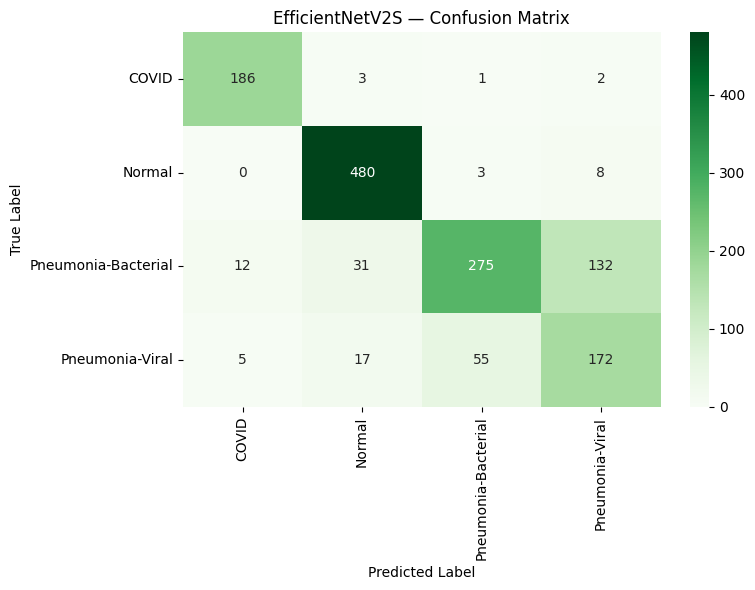

In [13]:
# ── CLASSIFICATION REPORT & CONFUSION MATRIX ──────────────────────────────────
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes

print('\n📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'{MODEL_NAME} — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

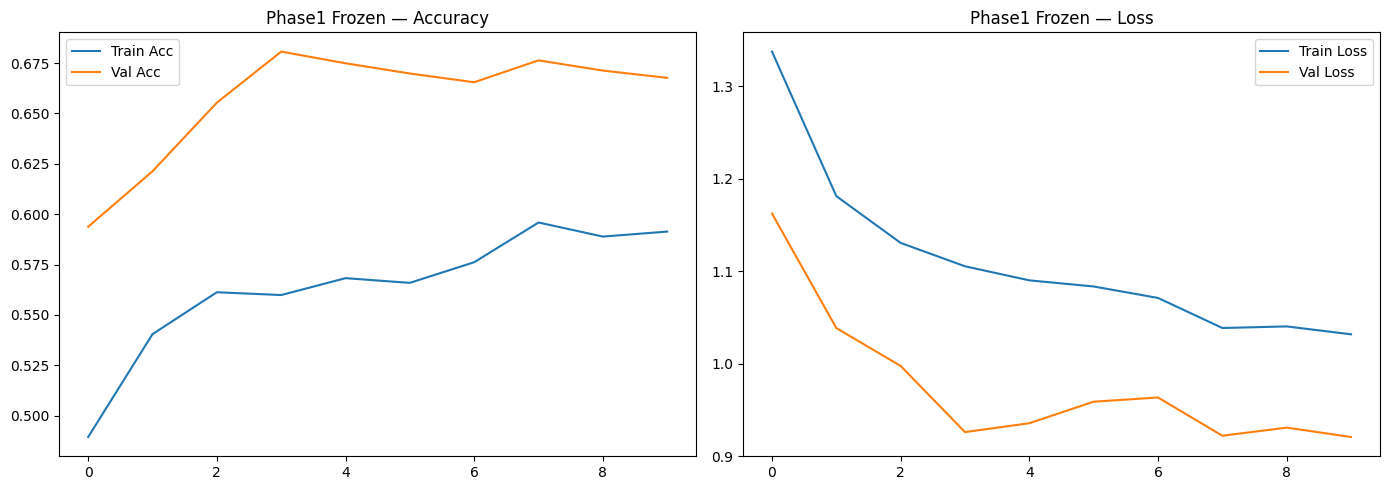

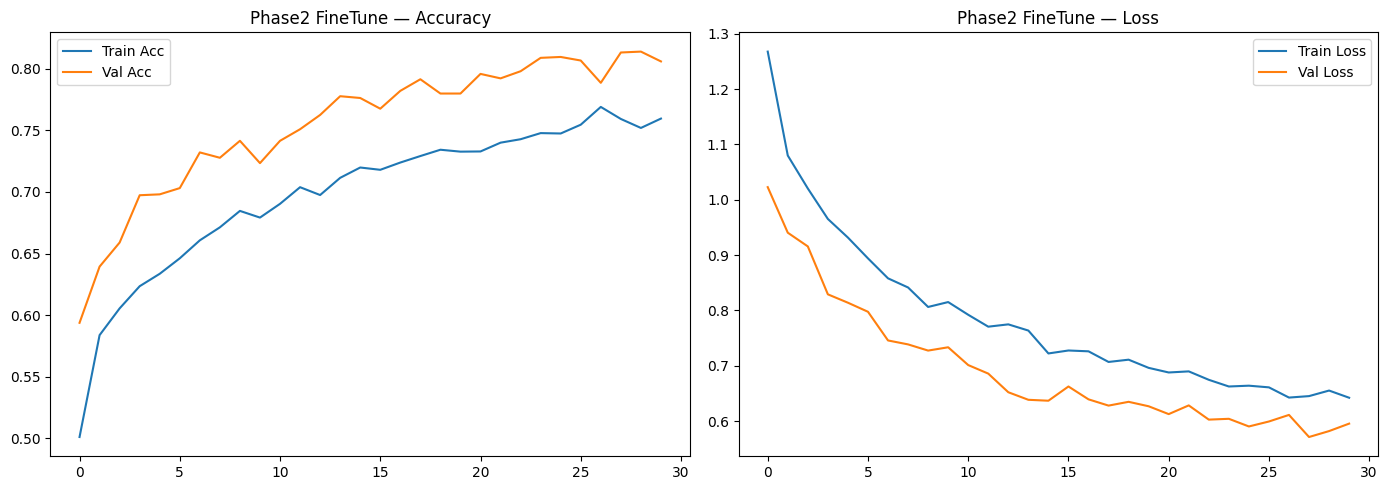

In [14]:
# ── TRAINING HISTORY PLOTS ────────────────────────────────────────────────────
def plot_history_from_csv(log_path, title):
    if not os.path.exists(log_path):
        print(f'{log_path} not found'); return
    df = pd.read_csv(log_path)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(df['accuracy'], label='Train Acc')
    axes[0].plot(df['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'{title} — Accuracy'); axes[0].legend()
    axes[1].plot(df['loss'], label='Train Loss')
    axes[1].plot(df['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} — Loss'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, f'history_{title.replace(" ","_")}.png'), dpi=150)
    plt.show()

plot_history_from_csv(LOG_FROZEN, 'Phase1 Frozen')
plot_history_from_csv(LOG_FINE,   'Phase2 FineTune')

In [15]:
# ── SAVE FINAL MODEL ──────────────────────────────────────────────────────────
FINAL_PATH = os.path.join(WORK_DIR, f'{MODEL_NAME}_final.keras')
model.save(FINAL_PATH)
print(f'✅ Final model saved → {FINAL_PATH}')

✅ Final model saved → ./efficientnetv2s_workspace\EfficientNetV2S_final.keras
